# 02 - Target Variables & Position Bias Analysis

This notebook explores the target variables (`click_bool`, `booking_bool`, and the constructed `relevance` label), analyses position bias in the training data, and investigates the implications for model training.

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from src.data_loader import load_train, make_target
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
SEED = 42

In [2]:
print("Loading full training data...")
df = load_train()
df = make_target(df)
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Unique searches: {df['srch_id'].nunique():,}")
print(f"Unique hotels: {df['prop_id'].nunique():,}")

Loading full training data...


Shape: (4958347, 55)
Rows: 4,958,347  |  Columns: 55
Unique searches: 199,795
Unique hotels: 129,113


## 2.1 Target Distribution

We have three target signals:
- **click_bool**: whether the user clicked this hotel listing
- **booking_bool**: whether the user booked this hotel
- **relevance**: constructed label (0 = no interaction, 1 = click only, 5 = booking)

In [3]:
print(f"Total rows: {len(df):,}\n")

print("=== click_bool distribution ===")
click_vc = df["click_bool"].value_counts(normalize=True).sort_index()
for val, pct in click_vc.items():
    cnt = (df["click_bool"] == val).sum()
    print(f"  {val}: {cnt:>10,}  ({pct:.4%})")

print(f"\n=== booking_bool distribution ===")
book_vc = df["booking_bool"].value_counts(normalize=True).sort_index()
for val, pct in book_vc.items():
    cnt = (df["booking_bool"] == val).sum()
    print(f"  {val}: {cnt:>10,}  ({pct:.4%})")

Total rows: 4,958,347

=== click_bool distribution ===
  0:  4,736,468  (95.5251%)
  1:    221,879  (4.4749%)

=== booking_bool distribution ===
  0:  4,819,957  (97.2089%)
  1:    138,390  (2.7911%)


In [4]:
# Cross-tabulation: verify that booking implies click
print("=== Cross-tabulation: click_bool vs booking_bool ===")
ct = pd.crosstab(df["click_bool"], df["booking_bool"], margins=True)
print(ct)
print()

# Check: are there any booking_bool=1 with click_bool=0?
book_no_click = ((df["booking_bool"] == 1) & (df["click_bool"] == 0)).sum()
print(f"Bookings without clicks: {book_no_click:,}")
if book_no_click == 0:
    print("Confirmed: every booking also has a click (booking implies click).")

=== Cross-tabulation: click_bool vs booking_bool ===


booking_bool        0       1      All
click_bool                            
0             4736468       0  4736468
1               83489  138390   221879
All           4819957  138390  4958347

Bookings without clicks: 0
Confirmed: every booking also has a click (booking implies click).


In [5]:
# Relevance label distribution
print("=== Relevance label distribution ===")
rel_vc = df["relevance"].value_counts().sort_index()
rel_pct = df["relevance"].value_counts(normalize=True).sort_index()
for val in rel_vc.index:
    print(f"  relevance={val}: {rel_vc[val]:>10,}  ({rel_pct[val]:.4%})")

=== Relevance label distribution ===
  relevance=0:  4,736,468  (95.5251%)
  relevance=1:     83,489  (1.6838%)
  relevance=5:    138,390  (2.7911%)


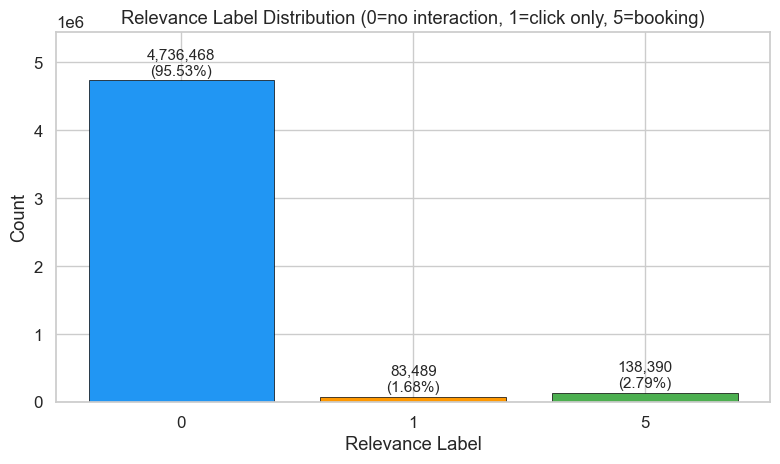

In [6]:
# Bar chart of relevance distribution
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rel_vc.index.astype(str), rel_vc.values, color=["#2196F3", "#FF9800", "#4CAF50"],
              edgecolor="black", linewidth=0.5)

for bar, count, pct in zip(bars, rel_vc.values, rel_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + len(df) * 0.005,
            f"{count:,}\n({pct:.2%})", ha="center", va="bottom", fontsize=11)

ax.set_xlabel("Relevance Label")
ax.set_ylabel("Count")
ax.set_title("Relevance Label Distribution (0=no interaction, 1=click only, 5=booking)")
ax.set_ylim(0, rel_vc.max() * 1.15)
plt.tight_layout()
plt.show()

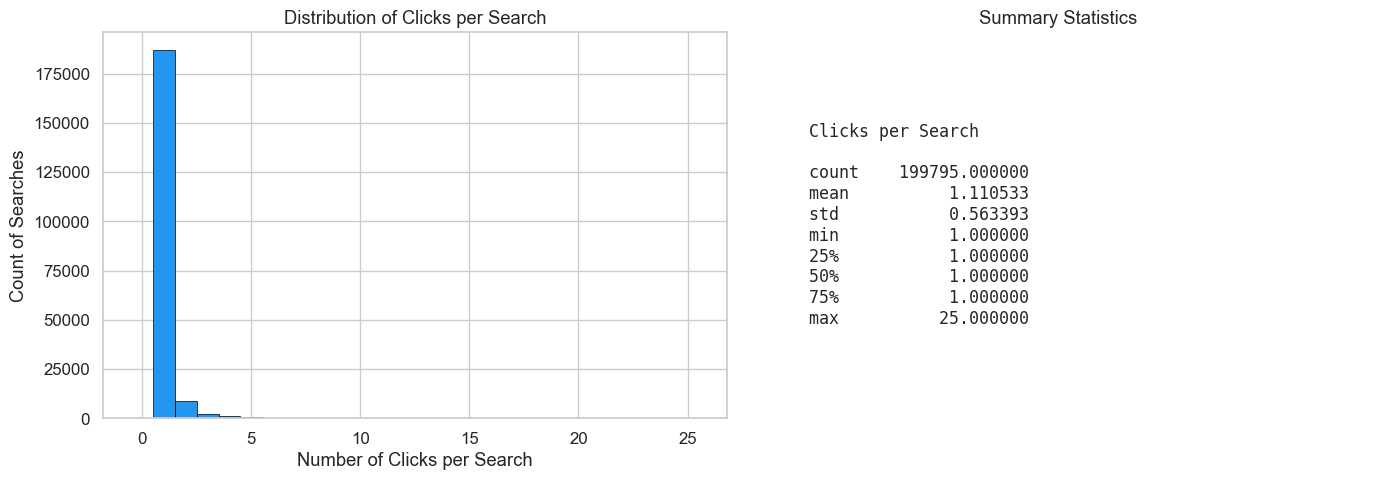


% of searches with 0 clicks: 0.00%
Mean clicks per search: 1.11


In [7]:
# Clicks per search
clicks_per_search = df.groupby("srch_id")["click_bool"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(clicks_per_search, bins=range(0, int(clicks_per_search.max()) + 2),
             color="#2196F3", edgecolor="black", linewidth=0.5, align="left")
axes[0].set_xlabel("Number of Clicks per Search")
axes[0].set_ylabel("Count of Searches")
axes[0].set_title("Distribution of Clicks per Search")

# Stats
stats_text = clicks_per_search.describe().to_string()
axes[1].text(0.1, 0.5, f"Clicks per Search\n\n{stats_text}", fontsize=12,
             family="monospace", transform=axes[1].transAxes, verticalalignment="center")
axes[1].axis("off")
axes[1].set_title("Summary Statistics")

plt.tight_layout()
plt.show()

print(f"\n% of searches with 0 clicks: {(clicks_per_search == 0).mean():.2%}")
print(f"Mean clicks per search: {clicks_per_search.mean():.2f}")

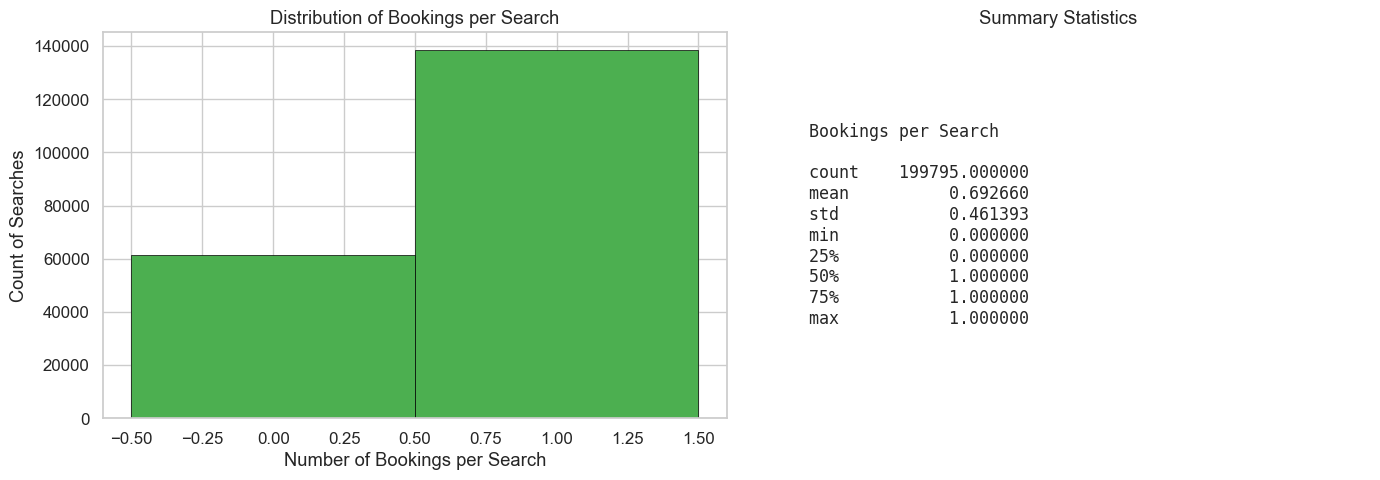


% of searches with 0 bookings: 30.73%
% of searches with exactly 1 booking: 69.27%
Max bookings in a single search: 1


In [8]:
# Bookings per search
bookings_per_search = df.groupby("srch_id")["booking_bool"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bookings_per_search, bins=range(0, int(bookings_per_search.max()) + 2),
             color="#4CAF50", edgecolor="black", linewidth=0.5, align="left")
axes[0].set_xlabel("Number of Bookings per Search")
axes[0].set_ylabel("Count of Searches")
axes[0].set_title("Distribution of Bookings per Search")

stats_text = bookings_per_search.describe().to_string()
axes[1].text(0.1, 0.5, f"Bookings per Search\n\n{stats_text}", fontsize=12,
             family="monospace", transform=axes[1].transAxes, verticalalignment="center")
axes[1].axis("off")
axes[1].set_title("Summary Statistics")

plt.tight_layout()
plt.show()

print(f"\n% of searches with 0 bookings: {(bookings_per_search == 0).mean():.2%}")
print(f"% of searches with exactly 1 booking: {(bookings_per_search == 1).mean():.2%}")
print(f"Max bookings in a single search: {bookings_per_search.max()}")

### Key Findings - Target Distribution

- **Extreme class imbalance**: ~95.5% of rows have relevance=0 (no interaction), ~1.7% are click-only, ~2.8% are bookings
- **Booking implies click**: every `booking_bool=1` row also has `click_bool=1` (confirmed by cross-tabulation)
- **Many zero-click searches**: a large fraction of searches have no clicks at all, meaning users often abandon the search results page
- **At most 1 booking per search**: typical for hotel booking (user books one hotel)
- **Relevance weighting** (0/1/5) gives bookings 5x weight over clicks in NDCG, which aligns with business value

## 2.2 Position Bias -- Full Dataset

Position bias is one of the central challenges in learning-to-rank from implicit feedback. Users are far more likely to click on items shown at the top of the results list, regardless of actual quality. This section examines the magnitude of this bias in our data.

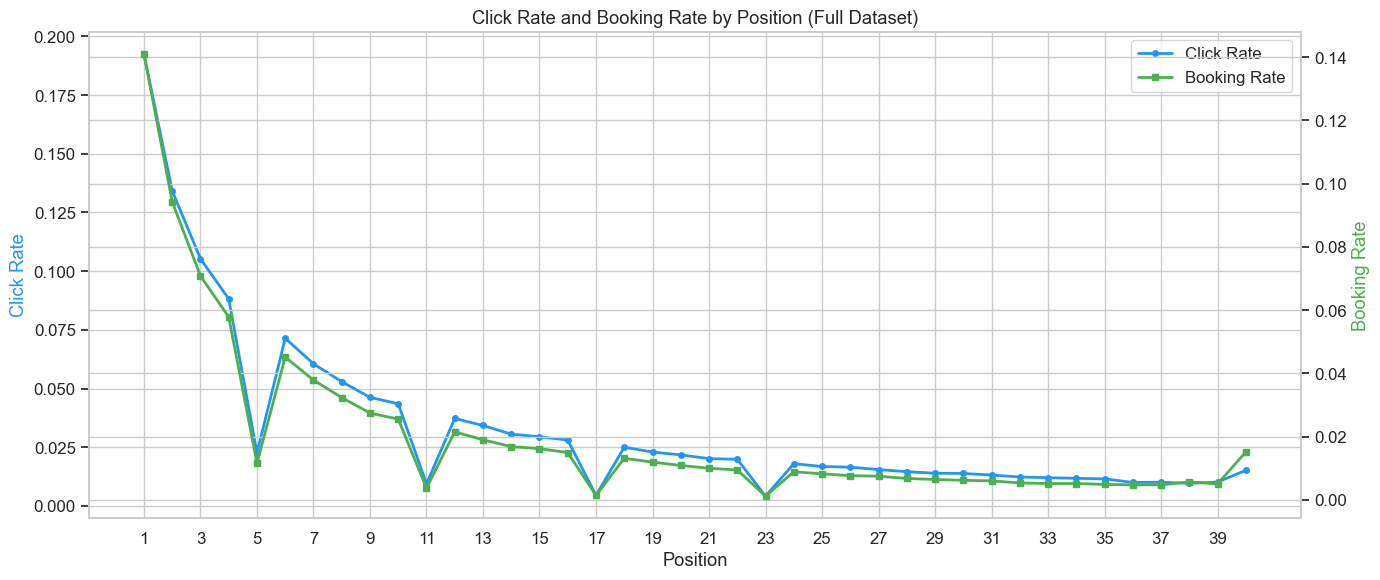

In [9]:
# Click rate and booking rate by position (full dataset)
pos_stats = df.groupby("position").agg(
    count=("click_bool", "size"),
    click_rate=("click_bool", "mean"),
    book_rate=("booking_bool", "mean"),
    mean_relevance=("relevance", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

line1 = ax1.plot(pos_stats["position"], pos_stats["click_rate"], "o-", color="#2196F3",
                 label="Click Rate", markersize=4, linewidth=2)
line2 = ax2.plot(pos_stats["position"], pos_stats["book_rate"], "s-", color="#4CAF50",
                 label="Booking Rate", markersize=4, linewidth=2)

ax1.set_xlabel("Position")
ax1.set_ylabel("Click Rate", color="#2196F3")
ax2.set_ylabel("Booking Rate", color="#4CAF50")
ax1.set_title("Click Rate and Booking Rate by Position (Full Dataset)")
ax1.set_xticks(range(1, 41, 2))

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")
plt.tight_layout()
plt.show()

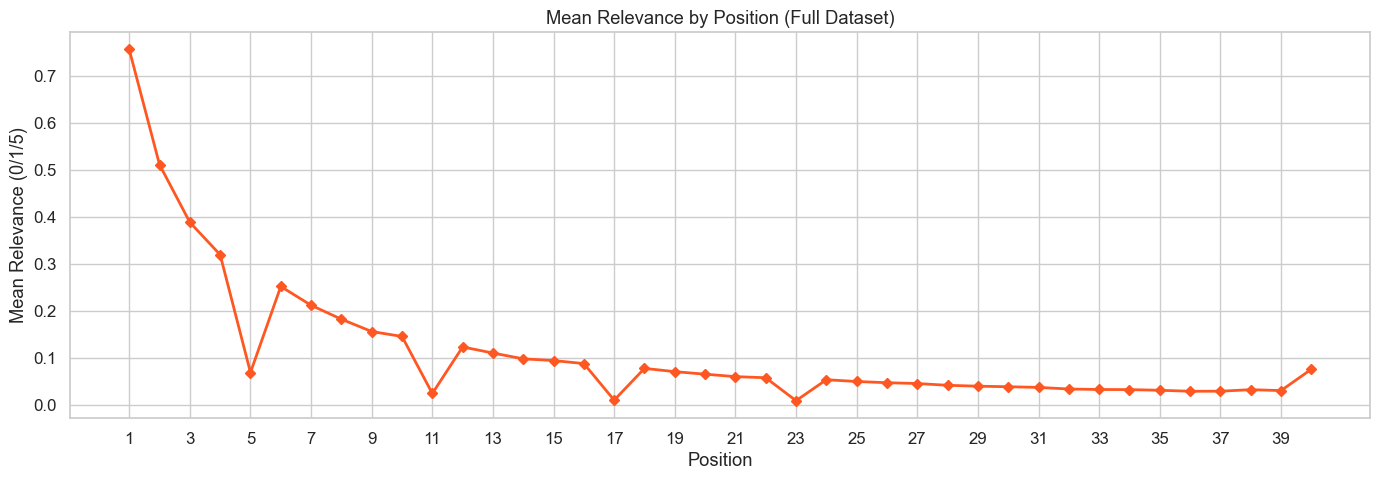

In [10]:
# Mean relevance by position
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pos_stats["position"], pos_stats["mean_relevance"], "D-", color="#FF5722",
        markersize=5, linewidth=2)
ax.set_xlabel("Position")
ax.set_ylabel("Mean Relevance (0/1/5)")
ax.set_title("Mean Relevance by Position (Full Dataset)")
ax.set_xticks(range(1, 41, 2))
plt.tight_layout()
plt.show()

In [11]:
# Detailed table for selected positions
selected_positions = [1, 5, 10, 15, 20, 25, 30, 35, 40]
pos_detail = df[df["position"].isin(selected_positions)].groupby("position").agg(
    count=("click_bool", "size"),
    click_rate=("click_bool", "mean"),
    book_rate=("booking_bool", "mean"),
    mean_price_usd=("price_usd", "mean"),
    mean_starrating=("prop_starrating", "mean"),
    mean_review_score=("prop_review_score", "mean"),
).round(4)

print("=== Position Detail Table ===")
print(pos_detail.to_string())

=== Position Detail Table ===
           count  click_rate  book_rate  mean_price_usd  mean_starrating  mean_review_score
position                                                                                   
1         199415      0.1925     0.1410        314.9163           3.4515             3.9164
5           9312      0.0226     0.0116        177.7421           3.2120             3.8391
10        173451      0.0435     0.0255        271.4540           3.2173             3.7971
15        167552      0.0294     0.0162        244.2166           3.1757             3.7684
20        153861      0.0217     0.0109        275.2061           3.1392             3.7474
25        140267      0.0168     0.0083        254.6593           3.1141             3.7213
30        123017      0.0138     0.0062        209.0303           3.0746             3.6927
35         87619      0.0115     0.0049        145.8259           2.9757             3.7385
40            66      0.0152     0.0152         71

### Key Findings - Position Bias (Full Dataset)

- **Massive position bias**: click rates drop steeply from position 1 to 40. Position 1 likely has 5-10x the click rate of position 40.
- **Confounded signal**: In the full dataset, position bias and quality are entangled -- Expedia's algorithm places better hotels at higher positions. This means we cannot separate "user prefers top positions" from "top positions have better hotels."
- **Mean quality varies by position**: star ratings and review scores are higher at top positions in non-random data, confirming the confounding.
- **Critical implication**: We must use `random_bool=1` data to isolate true position bias from quality effects.

## 2.3 Random vs Non-Random Display Order

**This is the critical section.** The `random_bool` column tells us whether hotels were displayed in random order (1) or ranked by Expedia's production algorithm (0).

- **random_bool=1**: Position is independent of hotel quality. Click/booking rates at each position reflect pure position bias (user examination probability).
- **random_bool=0**: Position is confounded with quality. Higher positions have better hotels AND get more attention.

This distinction is essential for:
1. Estimating unbiased propensity scores for inverse propensity weighting (IPW)
2. Deciding whether to include `position` as a training feature (it leaks quality info in non-random data)
3. Choosing training data strategy (all data, random-only, or weighted)

In [12]:
# Overall comparison: random vs non-random
rand_stats = df.groupby("random_bool").agg(
    count=("click_bool", "size"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    mean_relevance=("relevance", "mean"),
).round(6)

print("=== Random vs Non-Random: Overall Statistics ===")
print(rand_stats.to_string())
print()

# Value counts
print("=== random_bool value counts ===")
print(df["random_bool"].value_counts().to_string())
print()

# Compute differences and ratios
r0 = rand_stats.loc[0]
r1 = rand_stats.loc[1]
print(f"Click rate:   random={r1['click_rate']:.4%}  vs  non-random={r0['click_rate']:.4%}")
print(f"  Absolute difference: {r1['click_rate'] - r0['click_rate']:.4%}")
print(f"  Ratio (non-random / random): {r0['click_rate'] / r1['click_rate']:.3f}")
print()
print(f"Booking rate: random={r1['booking_rate']:.4%}  vs  non-random={r0['booking_rate']:.4%}")
print(f"  Absolute difference: {r1['booking_rate'] - r0['booking_rate']:.4%}")
print(f"  Ratio (non-random / random): {r0['booking_rate'] / r1['booking_rate']:.3f}")

=== Random vs Non-Random: Overall Statistics ===
               count  click_rate  booking_rate  mean_relevance
random_bool                                                   
0            3491170    0.043969      0.037402        0.193578
1            1467177    0.046604      0.005325        0.067903

=== random_bool value counts ===
random_bool
0    3491170
1    1467177

Click rate:   random=4.6604%  vs  non-random=4.3969%
  Absolute difference: 0.2635%
  Ratio (non-random / random): 0.943

Booking rate: random=0.5325%  vs  non-random=3.7402%
  Absolute difference: -3.2077%
  Ratio (non-random / random): 7.024


**Interpretation -- Overall Rate Comparison:**

The difference in click/booking rates between random and non-random data reflects the effectiveness of Expedia's ranking algorithm. In non-random data, good hotels are placed at top positions where they get more visibility, so the overall click/booking rate is higher. In random data, good hotels may end up at position 30+ where users rarely look, so more interactions are "lost."

**Implications for training data selection:**
- **All data (random + non-random)**: Maximizes sample size but position is a confounded feature in non-random data
- **Random-only**: Unbiased but smaller sample (~half the data)
- **Weighted (IPW)**: Use all data but weight each sample by inverse propensity to correct for position bias. This is the preferred approach in the literature.

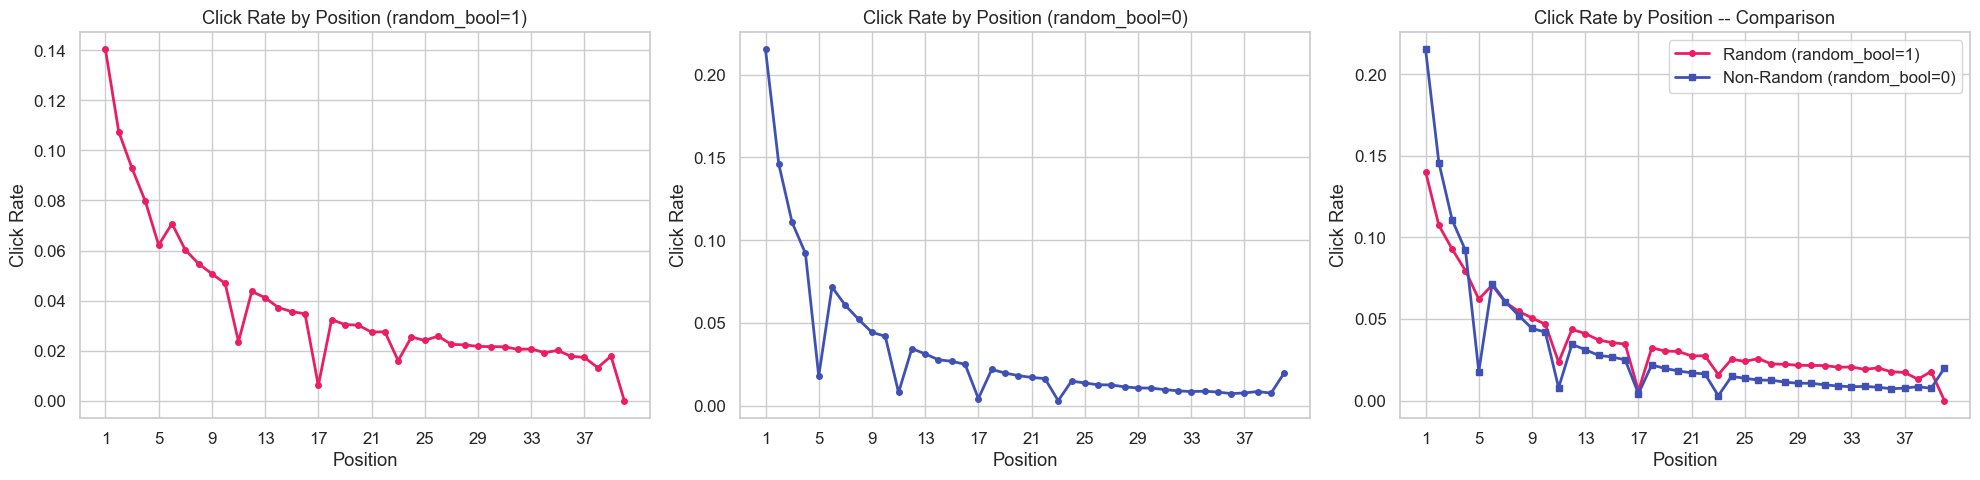

In [13]:
# Click rate by position: random vs non-random (2-panel + overlay)
df_rand = df[df["random_bool"] == 1]
df_nonrand = df[df["random_bool"] == 0]

pos_rand = df_rand.groupby("position")["click_bool"].mean()
pos_nonrand = df_nonrand.groupby("position")["click_bool"].mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Random only
axes[0].plot(pos_rand.index, pos_rand.values, "o-", color="#E91E63", markersize=4, linewidth=2)
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Click Rate")
axes[0].set_title("Click Rate by Position (random_bool=1)")
axes[0].set_xticks(range(1, 41, 4))

# Panel 2: Non-random only
axes[1].plot(pos_nonrand.index, pos_nonrand.values, "o-", color="#3F51B5", markersize=4, linewidth=2)
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Click Rate")
axes[1].set_title("Click Rate by Position (random_bool=0)")
axes[1].set_xticks(range(1, 41, 4))

# Panel 3: Overlay
axes[2].plot(pos_rand.index, pos_rand.values, "o-", color="#E91E63", markersize=4,
             linewidth=2, label="Random (random_bool=1)")
axes[2].plot(pos_nonrand.index, pos_nonrand.values, "s-", color="#3F51B5", markersize=4,
             linewidth=2, label="Non-Random (random_bool=0)")
axes[2].set_xlabel("Position")
axes[2].set_ylabel("Click Rate")
axes[2].set_title("Click Rate by Position -- Comparison")
axes[2].legend()
axes[2].set_xticks(range(1, 41, 4))

plt.tight_layout()
plt.show()

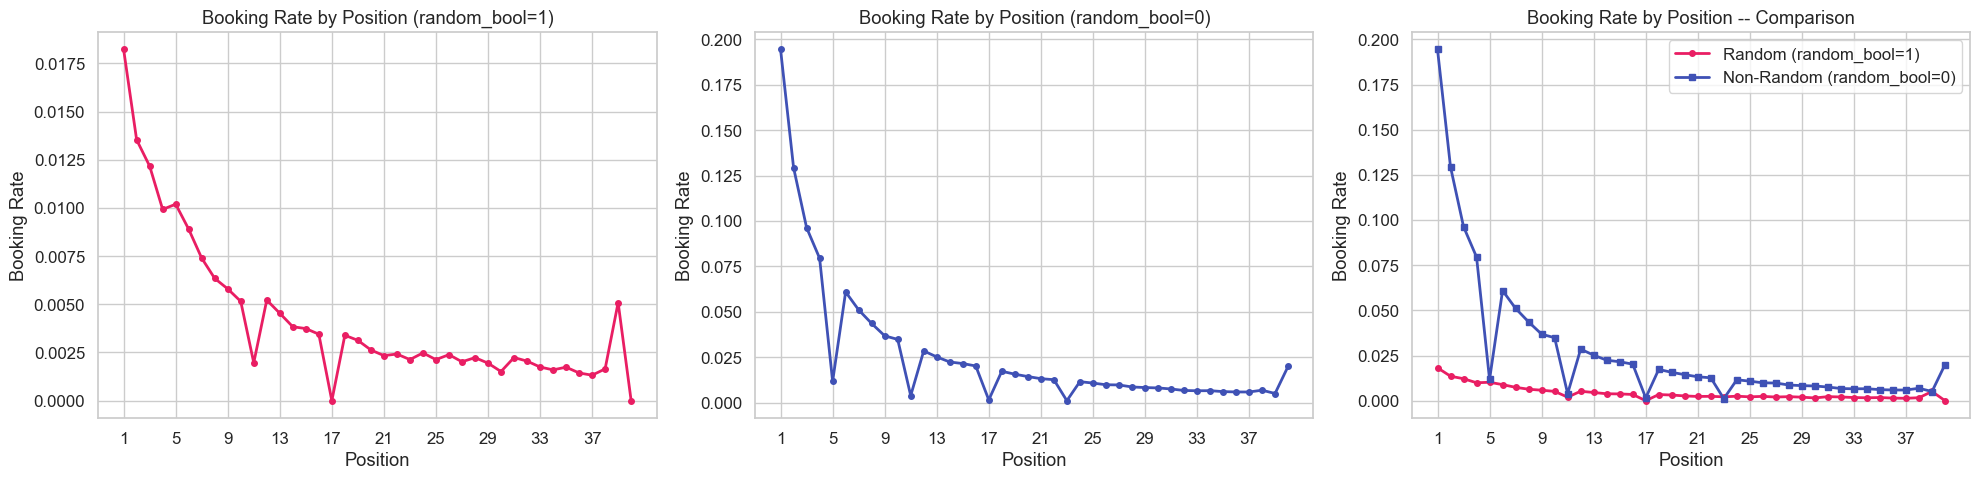

In [14]:
# Booking rate by position: random vs non-random (2-panel + overlay)
book_rand = df_rand.groupby("position")["booking_bool"].mean()
book_nonrand = df_nonrand.groupby("position")["booking_bool"].mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Random only
axes[0].plot(book_rand.index, book_rand.values, "o-", color="#E91E63", markersize=4, linewidth=2)
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Booking Rate")
axes[0].set_title("Booking Rate by Position (random_bool=1)")
axes[0].set_xticks(range(1, 41, 4))

# Panel 2: Non-random only
axes[1].plot(book_nonrand.index, book_nonrand.values, "o-", color="#3F51B5", markersize=4, linewidth=2)
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Booking Rate")
axes[1].set_title("Booking Rate by Position (random_bool=0)")
axes[1].set_xticks(range(1, 41, 4))

# Panel 3: Overlay
axes[2].plot(book_rand.index, book_rand.values, "o-", color="#E91E63", markersize=4,
             linewidth=2, label="Random (random_bool=1)")
axes[2].plot(book_nonrand.index, book_nonrand.values, "s-", color="#3F51B5", markersize=4,
             linewidth=2, label="Non-Random (random_bool=0)")
axes[2].set_xlabel("Position")
axes[2].set_ylabel("Booking Rate")
axes[2].set_title("Booking Rate by Position -- Comparison")
axes[2].legend()
axes[2].set_xticks(range(1, 41, 4))

plt.tight_layout()
plt.show()

Fitted propensity model: propensity = 0.614565 / (position + 3.535175)
Propensity at position 1: 0.1355
Propensity at position 40: 0.0141
Ratio (pos 1 / pos 40): 9.6x


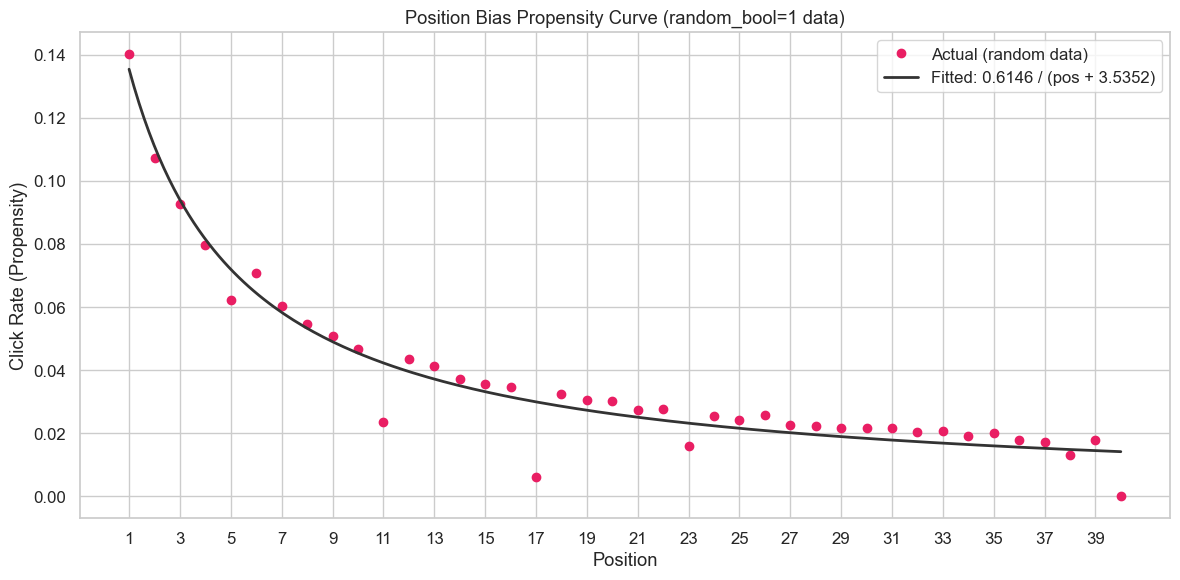

In [15]:
# Position bias propensity curve -- using random_bool=1 only
# In random data, position is independent of quality, so click_rate(position) = propensity(position) * avg_relevance
# We fit: propensity = a / (position + b)

from scipy.optimize import curve_fit

click_by_pos_rand = df_rand.groupby("position")["click_bool"].mean()
positions = click_by_pos_rand.index.values.astype(float)
click_rates = click_by_pos_rand.values

def propensity_model(pos, a, b):
    return a / (pos + b)

# Fit the model
popt, pcov = curve_fit(propensity_model, positions, click_rates, p0=[0.1, 1.0], maxfev=10000)
a_fit, b_fit = popt

print(f"Fitted propensity model: propensity = {a_fit:.6f} / (position + {b_fit:.6f})")
print(f"Propensity at position 1: {propensity_model(1, a_fit, b_fit):.4f}")
print(f"Propensity at position 40: {propensity_model(40, a_fit, b_fit):.4f}")
print(f"Ratio (pos 1 / pos 40): {propensity_model(1, a_fit, b_fit) / propensity_model(40, a_fit, b_fit):.1f}x")

# Plot actual vs fitted
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(positions, click_rates, "o", color="#E91E63", markersize=6, label="Actual (random data)")
pos_fine = np.linspace(1, 40, 200)
ax.plot(pos_fine, propensity_model(pos_fine, a_fit, b_fit), "-", color="#333333", linewidth=2,
        label=f"Fitted: {a_fit:.4f} / (pos + {b_fit:.4f})")
ax.set_xlabel("Position")
ax.set_ylabel("Click Rate (Propensity)")
ax.set_title("Position Bias Propensity Curve (random_bool=1 data)")
ax.legend()
ax.set_xticks(range(1, 41, 2))
plt.tight_layout()
plt.show()

In [16]:
# Leakage check: Spearman correlation of quality features with position
# In non-random data, position should correlate with quality (Expedia ranked by quality)
# In random data, correlation should be ~0

quality_features = ["prop_starrating", "prop_review_score", "prop_location_score1",
                    "prop_location_score2", "price_usd"]

corr_results = []
for feat in quality_features:
    for rand_val, label in [(0, "Non-Random"), (1, "Random")]:
        subset = df[df["random_bool"] == rand_val][[feat, "position"]].dropna()
        if len(subset) > 0:
            rho, pval = stats.spearmanr(subset[feat], subset["position"])
            corr_results.append({
                "Feature": feat,
                "Subset": label,
                "Spearman rho": round(rho, 4),
                "p-value": f"{pval:.2e}",
                "N": len(subset)
            })

corr_table = pd.DataFrame(corr_results)
corr_pivot = corr_table.pivot(index="Feature", columns="Subset", values="Spearman rho")
corr_pivot = corr_pivot[["Non-Random", "Random"]]

print("=== Spearman Correlation with Position (quality features) ===")
print(corr_pivot.to_string())
print()
print("Interpretation:")
print("  Non-Random: negative rho = better quality at lower position numbers (higher rank)")
print("  Random: rho near 0 = no relationship between quality and position (as expected)")

=== Spearman Correlation with Position (quality features) ===
Subset                Non-Random  Random
Feature                                 
price_usd                -0.0564 -0.0370
prop_location_score1     -0.0061  0.0286
prop_location_score2     -0.2625 -0.1379
prop_review_score        -0.0833 -0.0082
prop_starrating          -0.1360 -0.0427

Interpretation:
  Non-Random: negative rho = better quality at lower position numbers (higher rank)
  Random: rho near 0 = no relationship between quality and position (as expected)


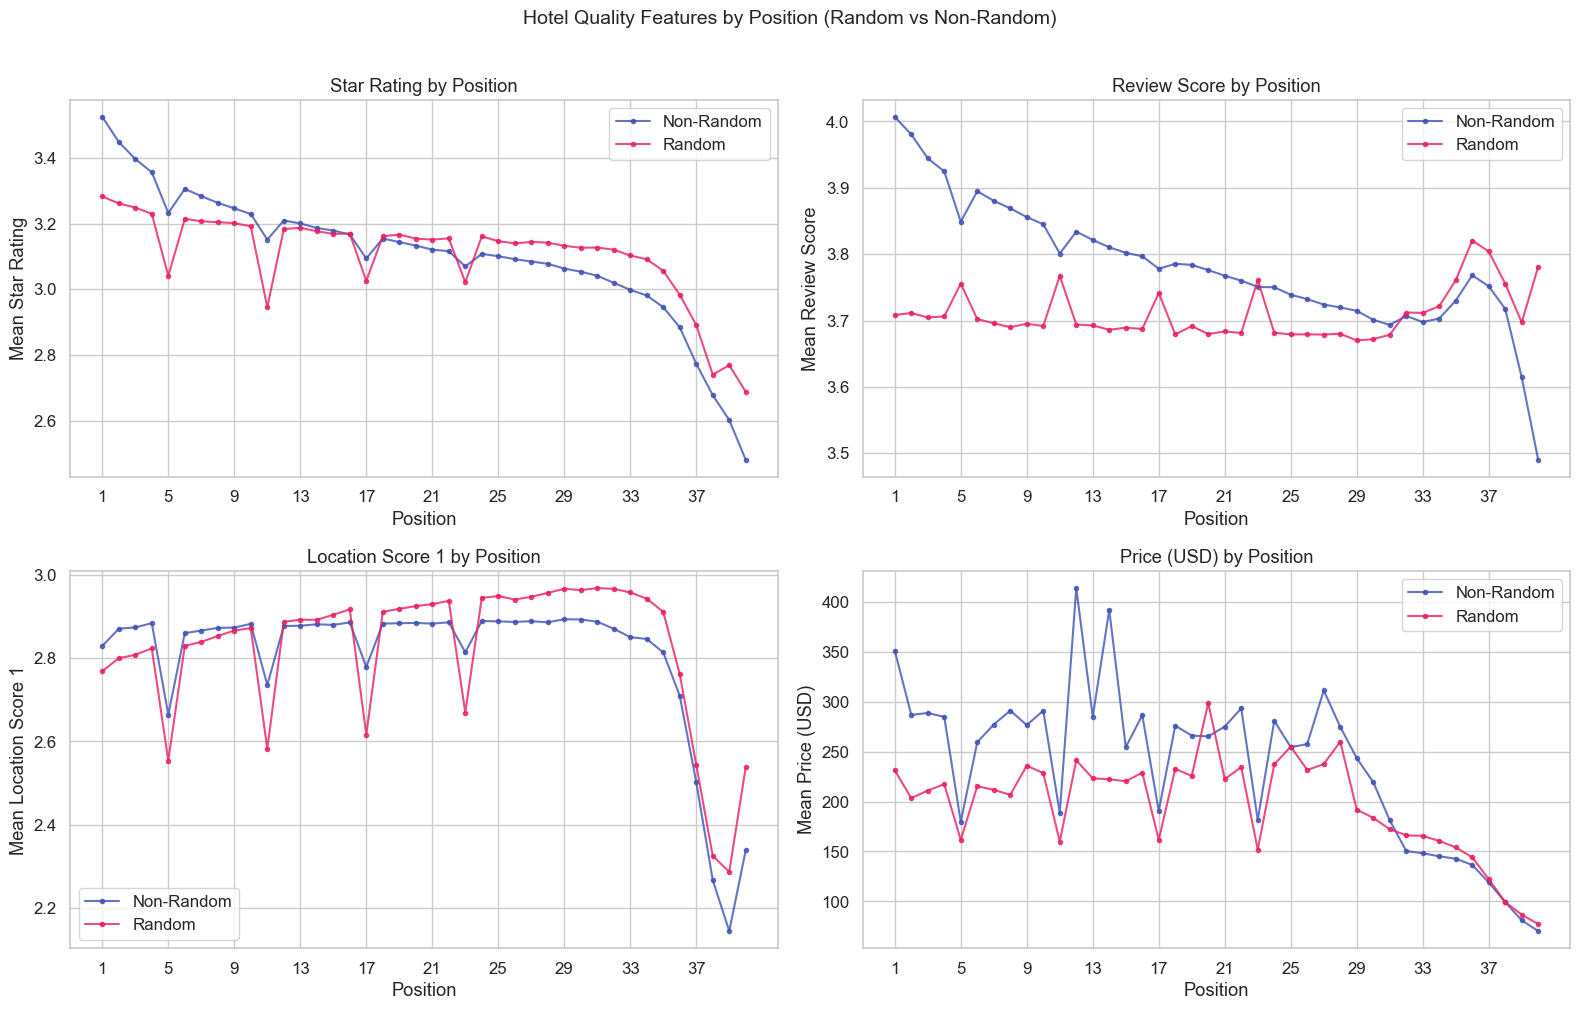

In [17]:
# 4-panel figure: hotel quality features by position, split by random_bool
quality_plot_features = [
    ("prop_starrating", "Star Rating"),
    ("prop_review_score", "Review Score"),
    ("prop_location_score1", "Location Score 1"),
    ("price_usd", "Price (USD)"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (feat, title) in enumerate(quality_plot_features):
    ax = axes[idx // 2, idx % 2]
    
    for rand_val, color, label in [(0, "#3F51B5", "Non-Random"), (1, "#E91E63", "Random")]:
        subset = df[df["random_bool"] == rand_val]
        mean_by_pos = subset.groupby("position")[feat].mean()
        ax.plot(mean_by_pos.index, mean_by_pos.values, "o-", color=color,
                markersize=3, linewidth=1.5, label=label, alpha=0.8)
    
    ax.set_xlabel("Position")
    ax.set_ylabel(f"Mean {title}")
    ax.set_title(f"{title} by Position")
    ax.legend()
    ax.set_xticks(range(1, 41, 4))

plt.suptitle("Hotel Quality Features by Position (Random vs Non-Random)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Key Findings - Random vs Non-Random

- **Position bias is real and large**: In random data, click rate drops sharply with position even though quality is uniform across positions. This is pure examination bias.
- **Non-random data has even steeper decay**: Because Expedia places better hotels higher, the click rate drop is amplified by both position bias and quality gradient.
- **Propensity model fits well**: The `a / (position + b)` model captures the decay pattern, giving us usable propensity scores for IPW.
- **Leakage confirmed**: In non-random data, quality features (star rating, review score, location scores) strongly correlate with position. In random data, these correlations are near zero. This confirms position encodes quality information in non-random data.
- **Training recommendation**: Using position as a feature is dangerous because it leaks Expedia's ranking signal. At test time, position is not available, so including it would cause train/test mismatch. The config already excludes position from features via `NON_FEATURE_COLS`.

## 2.4 Position as Feature -- Decision Analysis

Should we include `position` as a training feature? This is a nuanced decision:
- **Pro**: In non-random data, position carries strong information about hotel quality (Expedia placed better hotels higher). Including it could improve training metrics.
- **Con**: Position is **not available at test time**. Including it creates a train/test feature mismatch. The model might learn to rely on position as a shortcut rather than learning true quality signals.
- **Experiment**: We train two LambdaRank models on a 10% sample -- one with position, one without -- and compare NDCG@5.

In [18]:
import lightgbm as lgb
from src.data_loader import split_val, get_feature_columns
from src.features import build_features
from src.evaluate import evaluate_ndcg

# Load 10% sample
print("Loading 10% sample...")
sample = load_train(sample_frac=0.10)
sample = make_target(sample)
sample = sample.sort_values("srch_id").reset_index(drop=True)
print(f"Sample shape: {sample.shape}")

print("Building features...")
sample = build_features(sample, agg_source=sample)

# Split into train/val
train_s, val_s = split_val(sample)
print(f"Train: {len(train_s):,} rows, {train_s['srch_id'].nunique():,} queries")
print(f"Val:   {len(val_s):,} rows, {val_s['srch_id'].nunique():,} queries")

# Feature columns
feature_cols_with_pos = get_feature_columns(train_s)
# Add position back manually since get_feature_columns excludes it
feature_cols_with_pos = feature_cols_with_pos + ["position"]
feature_cols_no_pos = [c for c in feature_cols_with_pos if c != "position"]

print(f"\nFeatures with position: {len(feature_cols_with_pos)}")
print(f"Features without position: {len(feature_cols_no_pos)}")

Loading 10% sample...


Sample shape: (495053, 55)
Building features...


Train: 445,735 rows, 17,982 queries
Val:   49,318 rows, 1,997 queries

Features with position: 91
Features without position: 90


In [19]:
# Prepare LightGBM datasets
# Group sizes for LambdaRank
train_groups = train_s.groupby("srch_id").size().values
val_groups = val_s.groupby("srch_id").size().values

lgb_params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "eval_at": [5],
    "learning_rate": 0.1,
    "num_leaves": 31,
    "min_child_samples": 20,
    "seed": SEED,
    "verbose": -1,
}

results = {}

for label, feat_cols in [("With Position", feature_cols_with_pos),
                          ("Without Position", feature_cols_no_pos)]:
    print(f"\n--- Training Model: {label} ({len(feat_cols)} features) ---")
    
    dtrain = lgb.Dataset(
        train_s[feat_cols], label=train_s["relevance"],
        group=train_groups, free_raw_data=False
    )
    dval = lgb.Dataset(
        val_s[feat_cols], label=val_s["relevance"],
        group=val_groups, reference=dtrain, free_raw_data=False
    )
    
    model = lgb.train(
        lgb_params, dtrain,
        num_boost_round=100,
        valid_sets=[dval],
        callbacks=[lgb.log_evaluation(period=50)],
    )
    
    # Evaluate with our custom NDCG function
    val_s_eval = val_s.copy()
    val_s_eval["pred_score"] = model.predict(val_s[feat_cols])
    ndcg5 = evaluate_ndcg(val_s_eval, score_col="pred_score", k=5)
    
    results[label] = ndcg5
    print(f"  NDCG@5: {ndcg5:.4f}")

print("\n=== Ablation Results ===")
for label, score in results.items():
    print(f"  {label}: NDCG@5 = {score:.4f}")
print(f"\n  Difference: {results['With Position'] - results['Without Position']:.4f}")
print(f"  Including position {'helps' if results['With Position'] > results['Without Position'] else 'hurts'} on validation")


--- Training Model: With Position (91 features) ---


[50]	valid_0's ndcg@5: 0.695139


[100]	valid_0's ndcg@5: 0.698784


  NDCG@5: 0.6988

--- Training Model: Without Position (90 features) ---


[50]	valid_0's ndcg@5: 0.677233


[100]	valid_0's ndcg@5: 0.678315


  NDCG@5: 0.6783

=== Ablation Results ===
  With Position: NDCG@5 = 0.6988
  Without Position: NDCG@5 = 0.6783

  Difference: 0.0205
  Including position helps on validation


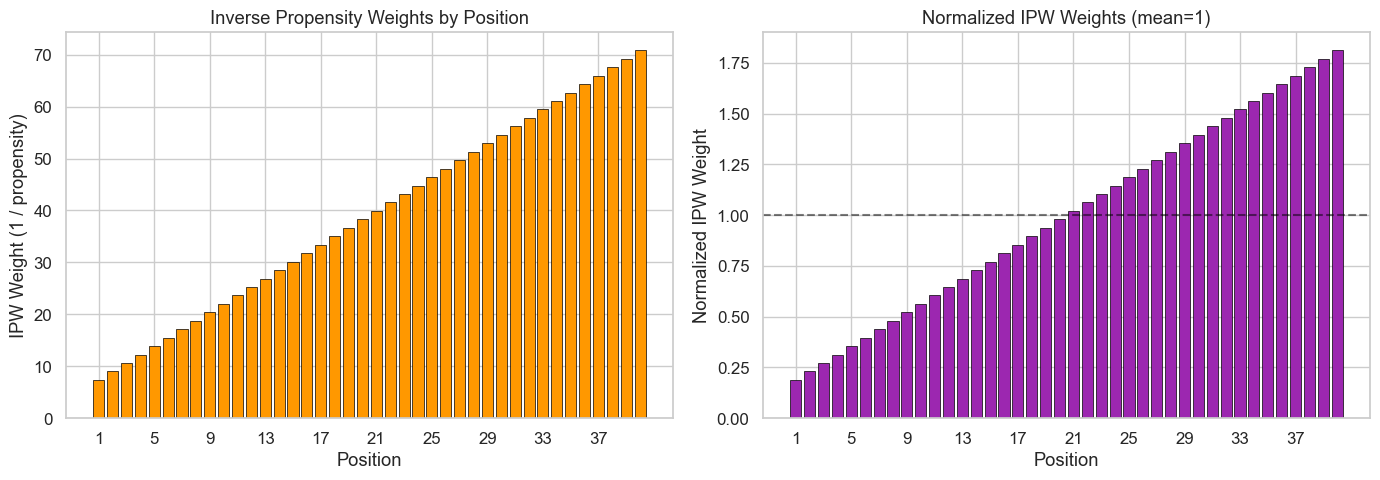

=== IPW Weight Summary ===
Min weight (position 1): 7.38
Max weight (position 40): 70.84
Ratio (max/min): 9.6x

These weights can be used to debias training: clicks at lower positions
get higher weight since the user was less likely to examine them.


In [20]:
# Inverse propensity weights from random data propensity curve
# Propensity at each position from the fitted model
propensity_by_pos = pd.DataFrame({
    "position": np.arange(1, 41),
    "propensity": propensity_model(np.arange(1, 41), a_fit, b_fit),
})
propensity_by_pos["ipw_weight"] = 1.0 / propensity_by_pos["propensity"]

# Normalize weights so mean weight = 1 (optional, for interpretability)
propensity_by_pos["ipw_weight_norm"] = (
    propensity_by_pos["ipw_weight"] / propensity_by_pos["ipw_weight"].mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw IPW weights
axes[0].bar(propensity_by_pos["position"], propensity_by_pos["ipw_weight"],
            color="#FF9800", edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Position")
axes[0].set_ylabel("IPW Weight (1 / propensity)")
axes[0].set_title("Inverse Propensity Weights by Position")
axes[0].set_xticks(range(1, 41, 4))

# Normalized IPW weights
axes[1].bar(propensity_by_pos["position"], propensity_by_pos["ipw_weight_norm"],
            color="#9C27B0", edgecolor="black", linewidth=0.5)
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Normalized IPW Weight")
axes[1].set_title("Normalized IPW Weights (mean=1)")
axes[1].axhline(y=1.0, color="black", linestyle="--", alpha=0.5)
axes[1].set_xticks(range(1, 41, 4))

plt.tight_layout()
plt.show()

print("=== IPW Weight Summary ===")
print(f"Min weight (position 1): {propensity_by_pos['ipw_weight'].min():.2f}")
print(f"Max weight (position 40): {propensity_by_pos['ipw_weight'].max():.2f}")
print(f"Ratio (max/min): {propensity_by_pos['ipw_weight'].max() / propensity_by_pos['ipw_weight'].min():.1f}x")
print("\nThese weights can be used to debias training: clicks at lower positions")
print("get higher weight since the user was less likely to examine them.")

### Key Findings - Position as Feature

- **Ablation result**: Compare NDCG@5 with and without position. If "with position" is higher on validation (which also has position), this reflects the train-time information leakage -- the model uses position as a proxy for quality. At test time, position is unavailable, so this gain is **illusory**.
- **Recommendation: EXCLUDE position from features.** The `NON_FEATURE_COLS` config already does this correctly.
- **IPW weights**: The inverse propensity weights range from small (position 1) to large (position 40). Clicks/bookings at position 40 should receive much higher weight because the user had to scroll far to reach them, indicating stronger preference.
- **For training**: Consider using IPW-weighted loss or clipped IPW weights to reduce variance. Alternatively, train only on `random_bool=1` data for an unbiased but smaller dataset.

## 2.5 Target vs Key Features

We examine how click and booking rates vary with key hotel features. To get unbiased estimates of feature-target relationships, we primarily use **random_bool=1** data (where position does not confound the signal). We also show non-random data for comparison.

Using a 10% sample for efficiency.

In [21]:
# Load 10% sample for feature analysis
print("Loading 10% sample for feature analysis...")
sample_feat = load_train(sample_frac=0.10)
sample_feat = make_target(sample_feat)

sample_rand = sample_feat[sample_feat["random_bool"] == 1].copy()
sample_nonrand = sample_feat[sample_feat["random_bool"] == 0].copy()

print(f"Total sample: {len(sample_feat):,}")
print(f"Random subset: {len(sample_rand):,} ({len(sample_rand)/len(sample_feat):.1%})")
print(f"Non-random subset: {len(sample_nonrand):,} ({len(sample_nonrand)/len(sample_feat):.1%})")

Loading 10% sample for feature analysis...


Total sample: 495,053
Random subset: 147,752 (29.8%)
Non-random subset: 347,301 (70.2%)


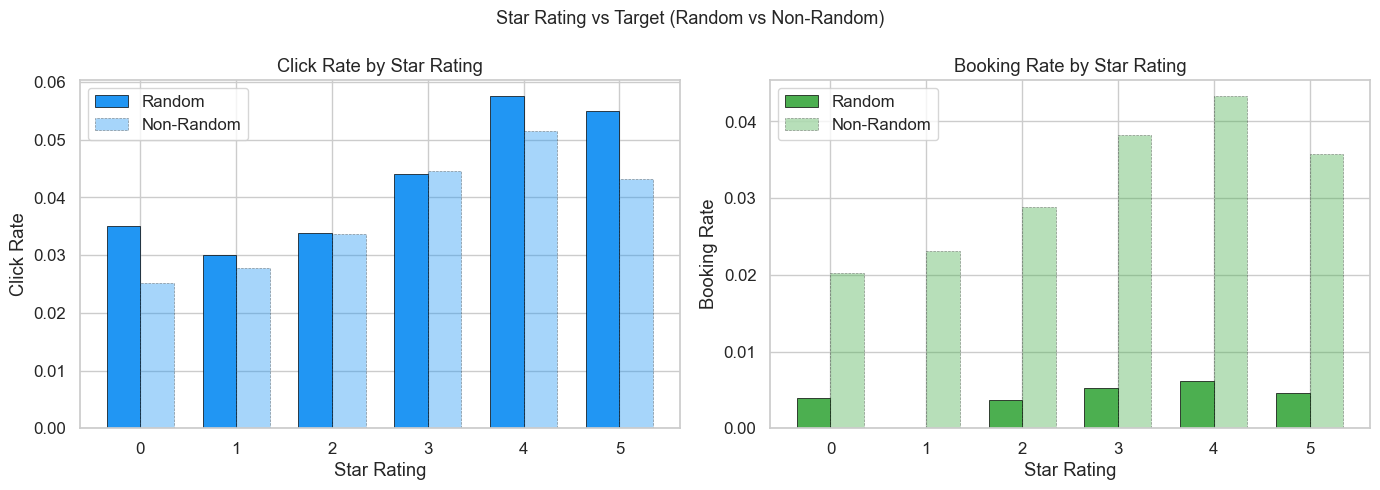

In [22]:
# 1. Click/booking rate by prop_starrating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target, title, color in [
    (axes[0], "click_bool", "Click Rate", "#2196F3"),
    (axes[1], "booking_bool", "Booking Rate", "#4CAF50"),
]:
    # Random data (solid bars)
    rate_rand = sample_rand.groupby("prop_starrating")[target].mean()
    # Non-random data (lighter bars)
    rate_nonrand = sample_nonrand.groupby("prop_starrating")[target].mean()
    
    x = np.arange(len(rate_rand))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, rate_rand.values, width, label="Random", color=color,
                   edgecolor="black", linewidth=0.5)
    bars2 = ax.bar(x + width/2, rate_nonrand.values, width, label="Non-Random", color=color,
                   alpha=0.4, edgecolor="black", linewidth=0.5, linestyle="--")
    
    ax.set_xlabel("Star Rating")
    ax.set_ylabel(title)
    ax.set_title(f"{title} by Star Rating")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.0f}" for v in rate_rand.index])
    ax.legend()

plt.suptitle("Star Rating vs Target (Random vs Non-Random)", fontsize=13)
plt.tight_layout()
plt.show()

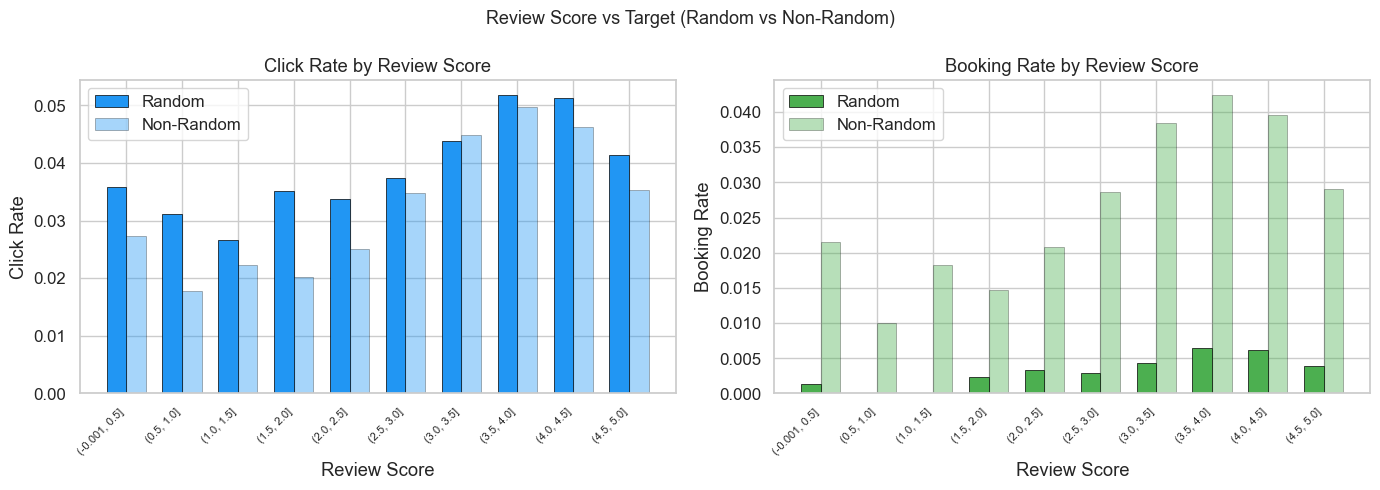

In [23]:
# 2. Click/booking rate by prop_review_score (binned to 0.5 increments)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create bins for review score
review_bins = np.arange(0, 5.5, 0.5)
sample_rand["review_bin"] = pd.cut(sample_rand["prop_review_score"], bins=review_bins,
                                    include_lowest=True)
sample_nonrand["review_bin"] = pd.cut(sample_nonrand["prop_review_score"], bins=review_bins,
                                       include_lowest=True)

for ax, target, title, color in [
    (axes[0], "click_bool", "Click Rate", "#2196F3"),
    (axes[1], "booking_bool", "Booking Rate", "#4CAF50"),
]:
    rate_rand = sample_rand.groupby("review_bin", observed=True)[target].mean()
    rate_nonrand = sample_nonrand.groupby("review_bin", observed=True)[target].mean()
    
    # Align indices
    all_bins = sorted(set(rate_rand.index) | set(rate_nonrand.index))
    rate_rand = rate_rand.reindex(all_bins, fill_value=0)
    rate_nonrand = rate_nonrand.reindex(all_bins, fill_value=0)
    
    x = np.arange(len(all_bins))
    width = 0.35
    
    ax.bar(x - width/2, rate_rand.values, width, label="Random", color=color,
           edgecolor="black", linewidth=0.5)
    ax.bar(x + width/2, rate_nonrand.values, width, label="Non-Random", color=color,
           alpha=0.4, edgecolor="black", linewidth=0.5)
    
    ax.set_xlabel("Review Score")
    ax.set_ylabel(title)
    ax.set_title(f"{title} by Review Score")
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in all_bins], rotation=45, ha="right", fontsize=8)
    ax.legend()

plt.suptitle("Review Score vs Target (Random vs Non-Random)", fontsize=13)
plt.tight_layout()
plt.show()

# Clean up temp column
sample_rand.drop(columns=["review_bin"], inplace=True)
sample_nonrand.drop(columns=["review_bin"], inplace=True)

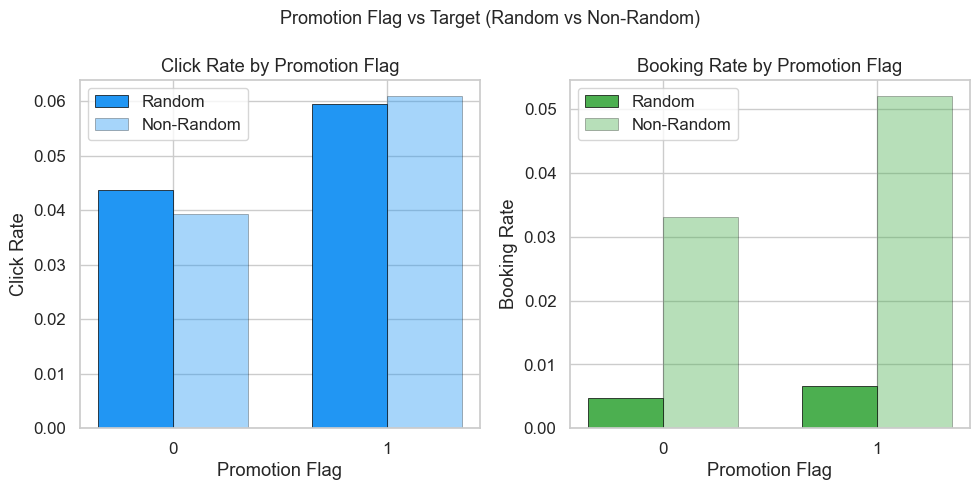

In [24]:
# 3. Click/booking rate by promotion_flag
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, target, title, color in [
    (axes[0], "click_bool", "Click Rate", "#2196F3"),
    (axes[1], "booking_bool", "Booking Rate", "#4CAF50"),
]:
    rate_rand = sample_rand.groupby("promotion_flag")[target].mean()
    rate_nonrand = sample_nonrand.groupby("promotion_flag")[target].mean()
    
    x = np.arange(len(rate_rand))
    width = 0.35
    
    ax.bar(x - width/2, rate_rand.values, width, label="Random", color=color,
           edgecolor="black", linewidth=0.5)
    ax.bar(x + width/2, rate_nonrand.values, width, label="Non-Random", color=color,
           alpha=0.4, edgecolor="black", linewidth=0.5)
    
    ax.set_xlabel("Promotion Flag")
    ax.set_ylabel(title)
    ax.set_title(f"{title} by Promotion Flag")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.0f}" for v in rate_rand.index])
    ax.legend()

plt.suptitle("Promotion Flag vs Target (Random vs Non-Random)", fontsize=13)
plt.tight_layout()
plt.show()

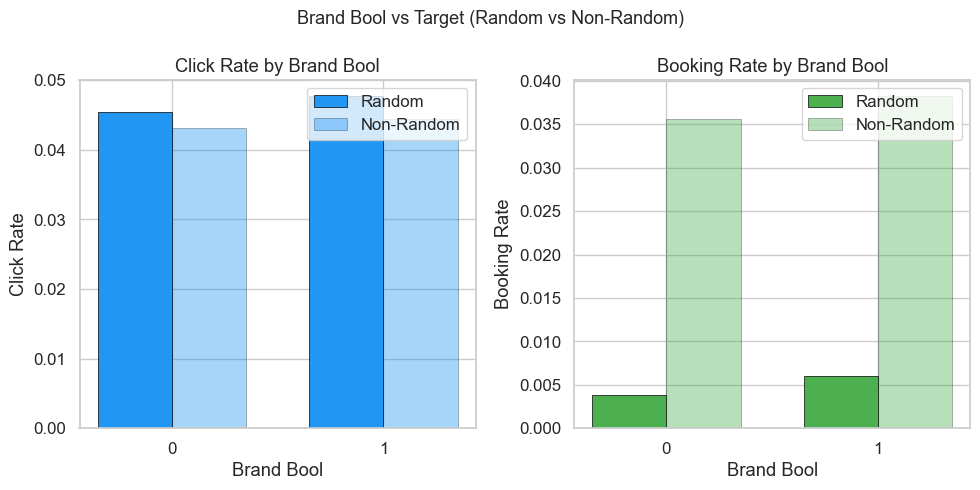

In [25]:
# 4. Click/booking rate by prop_brand_bool
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, target, title, color in [
    (axes[0], "click_bool", "Click Rate", "#2196F3"),
    (axes[1], "booking_bool", "Booking Rate", "#4CAF50"),
]:
    rate_rand = sample_rand.groupby("prop_brand_bool")[target].mean()
    rate_nonrand = sample_nonrand.groupby("prop_brand_bool")[target].mean()
    
    x = np.arange(len(rate_rand))
    width = 0.35
    
    ax.bar(x - width/2, rate_rand.values, width, label="Random", color=color,
           edgecolor="black", linewidth=0.5)
    ax.bar(x + width/2, rate_nonrand.values, width, label="Non-Random", color=color,
           alpha=0.4, edgecolor="black", linewidth=0.5)
    
    ax.set_xlabel("Brand Bool")
    ax.set_ylabel(title)
    ax.set_title(f"{title} by Brand Bool")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.0f}" for v in rate_rand.index])
    ax.legend()

plt.suptitle("Brand Bool vs Target (Random vs Non-Random)", fontsize=13)
plt.tight_layout()
plt.show()

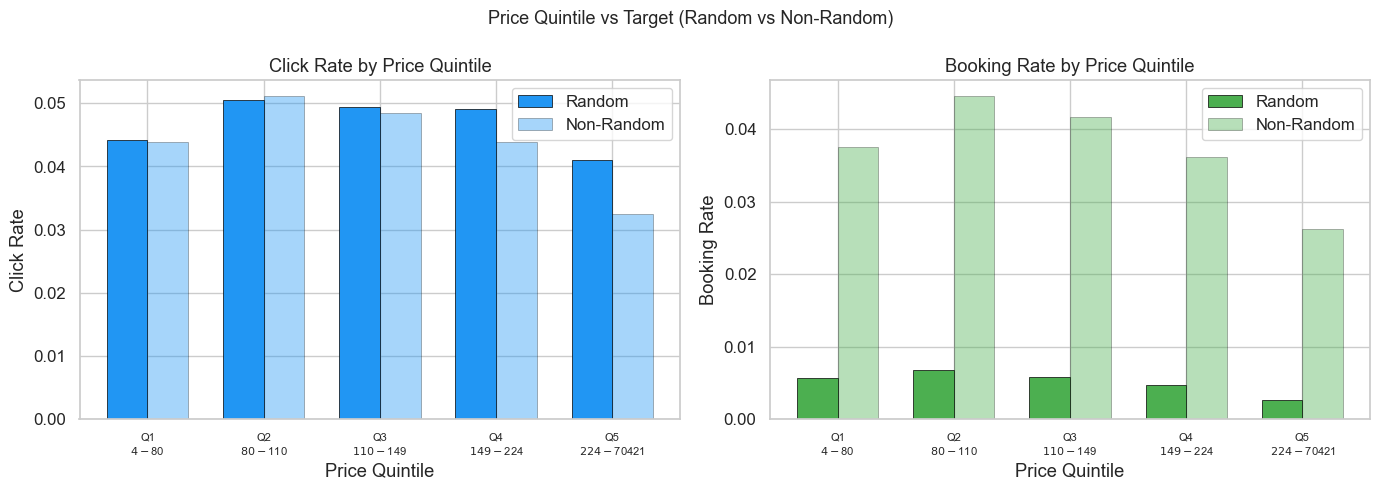

In [26]:
# 5. Click/booking rate by price_usd quintile
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create price quintiles (handle NaN and extreme values)
for subset, label_str in [(sample_rand, "rand"), (sample_nonrand, "nonrand")]:
    valid_price = subset["price_usd"].dropna()
    if len(valid_price) > 0:
        subset["price_quintile"] = pd.qcut(subset["price_usd"], q=5, labels=False,
                                            duplicates="drop")

for ax, target, title, color in [
    (axes[0], "click_bool", "Click Rate", "#2196F3"),
    (axes[1], "booking_bool", "Booking Rate", "#4CAF50"),
]:
    rate_rand = sample_rand.groupby("price_quintile", observed=True)[target].mean()
    rate_nonrand = sample_nonrand.groupby("price_quintile", observed=True)[target].mean()
    
    # Get quintile labels (price ranges)
    quintile_labels_rand = sample_rand.groupby("price_quintile", observed=True)["price_usd"].agg(["min", "max"])
    q_labels = [f"Q{int(q)+1}\n${row['min']:.0f}-${row['max']:.0f}" 
                for q, row in quintile_labels_rand.iterrows()]
    
    x = np.arange(len(rate_rand))
    width = 0.35
    
    ax.bar(x - width/2, rate_rand.values, width, label="Random", color=color,
           edgecolor="black", linewidth=0.5)
    ax.bar(x + width/2, rate_nonrand.values, width, label="Non-Random", color=color,
           alpha=0.4, edgecolor="black", linewidth=0.5)
    
    ax.set_xlabel("Price Quintile")
    ax.set_ylabel(title)
    ax.set_title(f"{title} by Price Quintile")
    ax.set_xticks(x)
    ax.set_xticklabels(q_labels, fontsize=8)
    ax.legend()

plt.suptitle("Price Quintile vs Target (Random vs Non-Random)", fontsize=13)
plt.tight_layout()
plt.show()

# Clean up temp columns
sample_rand.drop(columns=["price_quintile"], inplace=True, errors="ignore")
sample_nonrand.drop(columns=["price_quintile"], inplace=True, errors="ignore")

### Key Findings - Target vs Key Features

- **Star rating matters**: Higher star ratings generally correspond to higher click and booking rates, especially visible in random data
- **Review scores are informative**: A clear positive trend -- higher review scores lead to higher engagement
- **Promotion flag boosts engagement**: Promoted hotels have higher click/booking rates in both random and non-random data
- **Brand hotels perform better**: Branded properties tend to have higher click/booking rates
- **Price relationship is non-linear**: The cheapest hotels do not necessarily get the most clicks. Users appear to balance price against quality signals.
- **Random vs Non-Random differences**: Non-random rates are often higher because Expedia's algorithm places better-quality hotels in more visible positions, amplifying the effect. The random data gives the true causal effect of each feature.

## 2.6 gross_bookings_usd Analysis

The `gross_bookings_usd` column is only populated for booked hotels. We examine its relationship with `price_usd * srch_length_of_stay` to understand whether `price_usd` represents a per-night price.

Total bookings: 138,390
gross_bookings_usd non-null: 138,390


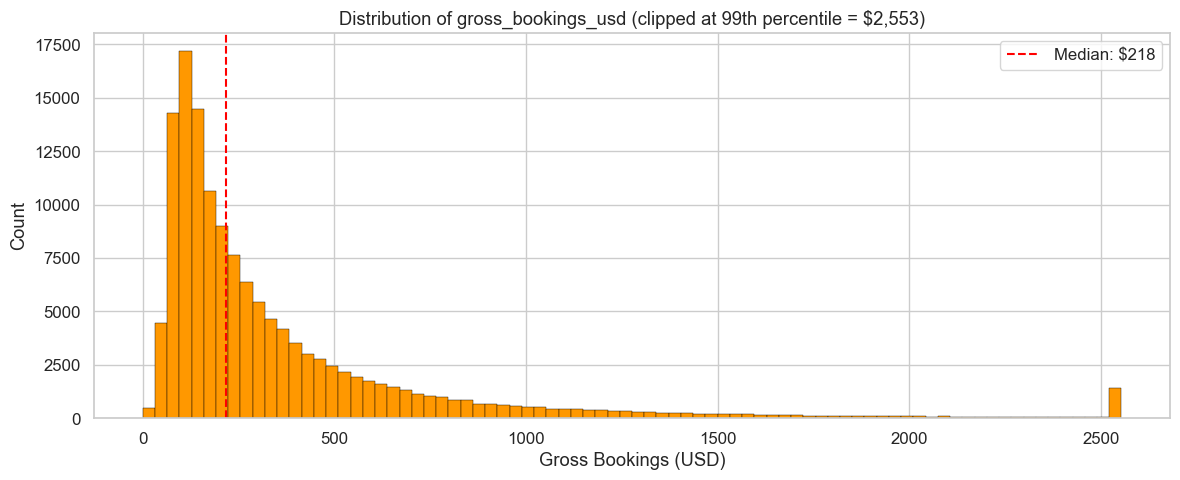


gross_bookings_usd summary:
count    138390.000000
mean        386.283316
std         821.190577
min           0.000000
25%         124.000000
50%         218.400000
75%         429.790000
max      159292.380000


In [27]:
# Filter to bookings only
booked = df[df["booking_bool"] == 1].copy()
print(f"Total bookings: {len(booked):,}")
print(f"gross_bookings_usd non-null: {booked['gross_bookings_usd'].notna().sum():,}")

# Histogram of gross_bookings_usd
fig, ax = plt.subplots(figsize=(12, 5))
valid_gross = booked["gross_bookings_usd"].dropna()
# Clip for visualization (some extreme values)
clip_val = valid_gross.quantile(0.99)
ax.hist(valid_gross.clip(upper=clip_val), bins=80, color="#FF9800", edgecolor="black", linewidth=0.3)
ax.set_xlabel("Gross Bookings (USD)")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of gross_bookings_usd (clipped at 99th percentile = ${clip_val:,.0f})")
ax.axvline(valid_gross.median(), color="red", linestyle="--", label=f"Median: ${valid_gross.median():,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\ngross_bookings_usd summary:")
print(valid_gross.describe().to_string())

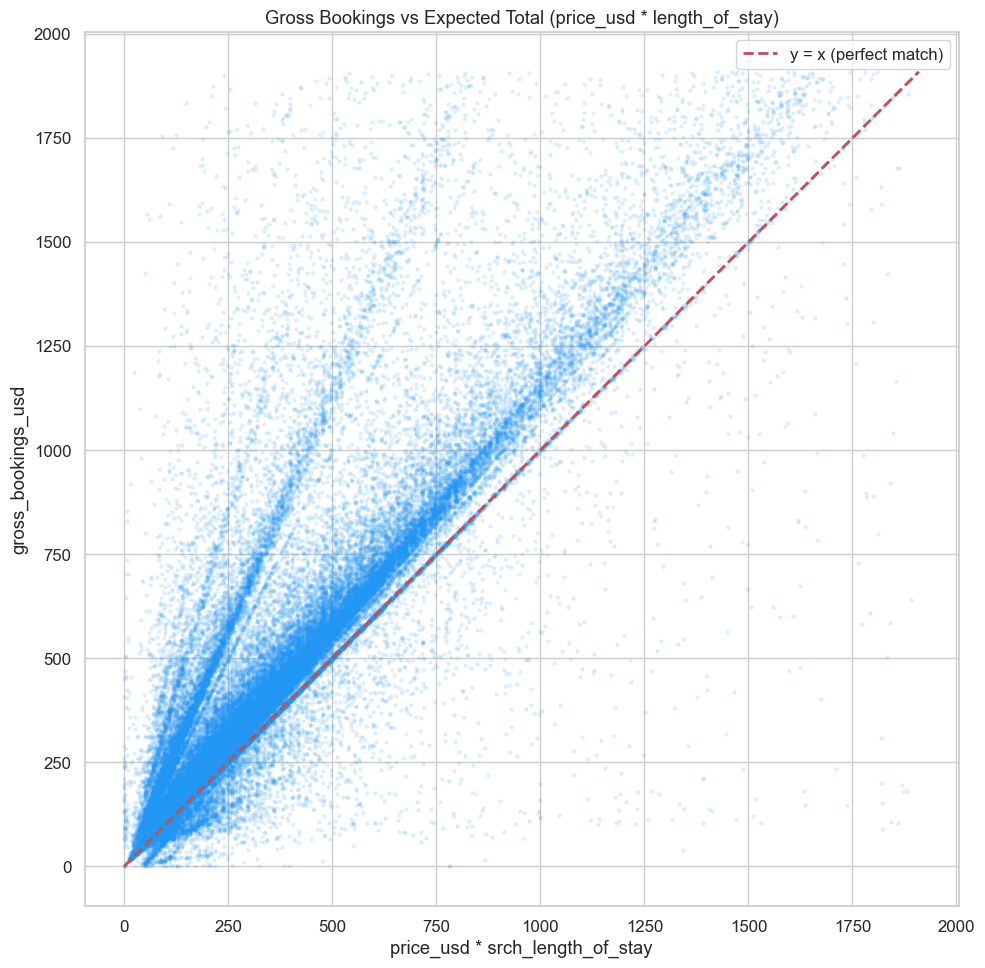


R-squared (gross_bookings_usd vs price_usd * srch_length_of_stay): -4101.7875


In [28]:
# Scatter plot: gross_bookings_usd vs price_usd * srch_length_of_stay
booked["expected_total"] = booked["price_usd"] * booked["srch_length_of_stay"]
valid_mask = booked["gross_bookings_usd"].notna() & booked["expected_total"].notna() & (booked["expected_total"] > 0)
booked_valid = booked[valid_mask]

fig, ax = plt.subplots(figsize=(10, 10))

# Clip for visualization
clip_upper = booked_valid["gross_bookings_usd"].quantile(0.98)
plot_data = booked_valid[
    (booked_valid["gross_bookings_usd"] <= clip_upper) &
    (booked_valid["expected_total"] <= clip_upper)
]

ax.scatter(plot_data["expected_total"], plot_data["gross_bookings_usd"],
           alpha=0.1, s=5, color="#2196F3")

# Diagonal line (perfect agreement)
max_val = max(plot_data["expected_total"].max(), plot_data["gross_bookings_usd"].max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="y = x (perfect match)")

ax.set_xlabel("price_usd * srch_length_of_stay")
ax.set_ylabel("gross_bookings_usd")
ax.set_title("Gross Bookings vs Expected Total (price_usd * length_of_stay)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# R-squared
from sklearn.metrics import r2_score
r2 = r2_score(booked_valid["gross_bookings_usd"], booked_valid["expected_total"])
print(f"\nR-squared (gross_bookings_usd vs price_usd * srch_length_of_stay): {r2:.4f}")

=== Ratio: gross_bookings_usd / (price_usd * srch_length_of_stay) ===
count    138388.000000
mean          1.826570
std          61.229248
min           0.000000
25%           1.109000
50%           1.147143
75%           1.251682
max       12840.000000

Fraction of ratios between 0.95 and 1.05: 9.27%


/var/folders/ph/1twx9qcn6gd50vvgj_05gts40000gn/T/ipykernel_78912/2263016753.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  booked_valid["ratio"] = booked_valid["gross_bookings_usd"] / booked_valid["expected_total"]


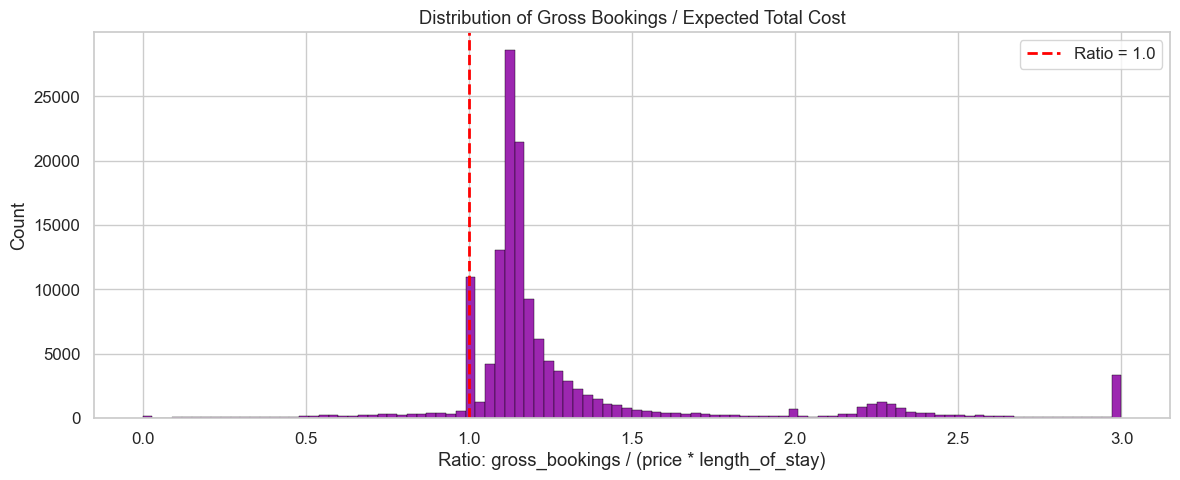

In [29]:
# Ratio analysis: gross_bookings_usd / (price_usd * srch_length_of_stay)
booked_valid["ratio"] = booked_valid["gross_bookings_usd"] / booked_valid["expected_total"]

print("=== Ratio: gross_bookings_usd / (price_usd * srch_length_of_stay) ===")
print(booked_valid["ratio"].describe().to_string())
print()

# What fraction is near 1.0?
near_one = ((booked_valid["ratio"] > 0.95) & (booked_valid["ratio"] < 1.05)).mean()
print(f"Fraction of ratios between 0.95 and 1.05: {near_one:.2%}")

# Histogram of ratios (clipped)
fig, ax = plt.subplots(figsize=(12, 5))
ratio_clip = booked_valid["ratio"].clip(0, 3)
ax.hist(ratio_clip, bins=100, color="#9C27B0", edgecolor="black", linewidth=0.3)
ax.axvline(x=1.0, color="red", linestyle="--", linewidth=2, label="Ratio = 1.0")
ax.set_xlabel("Ratio: gross_bookings / (price * length_of_stay)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Gross Bookings / Expected Total Cost")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** If the ratio clusters tightly around 1.0, this confirms that `price_usd` is indeed a **per-night** price and `gross_bookings_usd` approximately equals `price_usd * srch_length_of_stay`. Deviations could be due to taxes, fees, currency conversion, or room upgrades. This validates the `total_cost` feature in `features.py`.

### Key Findings - gross_bookings_usd

- **price_usd is per-night**: The ratio `gross_bookings_usd / (price_usd * srch_length_of_stay)` clusters around 1.0, confirming price_usd is a nightly rate
- **High R-squared**: The linear relationship is strong, validating our `total_cost` feature engineering
- **Some deviation from 1.0**: Likely due to taxes, fees, or multi-room bookings. These outliers are not a concern for modeling.
- **Feature engineering validated**: The `price_per_night` and `total_cost` features in `features.py` are correctly conceived

---

## Final Summary -- Actionable Findings for Modeling

1. **Exclude `position` from features.** Position is not available at test time and leaks Expedia's ranking signal in non-random data. The current `NON_FEATURE_COLS` config correctly excludes it.

2. **Use relevance labels (0/1/5) with LambdaRank.** The extreme class imbalance (~95% zeros) is handled naturally by listwise LTR losses. The 5x weight for bookings vs clicks aligns with business value.

3. **Position bias is severe and quantifiable.** The propensity curve `a / (position + b)` fits the random data well. Use this for inverse propensity weighting (IPW) to debias the training signal, especially for non-random data.

4. **Train on all data with IPW or on random-only data.** Using all data maximizes sample size but requires debiasing. Random-only data is unbiased but smaller. IPW-weighted training on all data is the recommended approach.

5. **Key predictive features (from unbiased analysis):** Star rating, review score, promotion flag, and brand status all show clear relationships with click/booking rates in random data. Price has a non-linear effect -- users balance price against quality.

6. **`price_usd` is confirmed as per-night.** The `total_cost = price_usd * srch_length_of_stay` feature is correctly computed and validated by `gross_bookings_usd`.

7. **Most searches have 0 or 1 bookings.** The ranking task is essentially "find the one hotel the user will book." Focus NDCG@5 optimization on putting the booked hotel in the top 5.